1. Motivation

Russia has historically experienced one of the world’s highest alcohol-related mortality rates, especially among working-age men. This project investigates how national alcohol control policies impacted consumption patterns over time.

We use datasets from OpenICPSR and Rosstat that track:
- Alcohol sales by beverage type
- Retail prices of vodka and other drinks
- Mortality indicators, such as poisoning and suicide
- And economic context (unemployment, population, GDP)

Our goal is to uncover how policy reforms in 2006, 2010, and 2012 affected alcohol consumption, especially vodka, and whether they had any measurable impact on health outcomes.




What is your dataset?
    We combined multiple dataset since using only one was not possible to convey the whole story we chose. Our datasets are

Datasets Used:
-  *"Demand for Alcohol Consumption in Russia and Its Implication for Mortality"* (regional_level_data.dta) Used for regional-level alcohol price data by year. https://www.openicpsr.org/openicpsr/project/113586/version/V1/view?path=/openicpsr/113586/fcr:versions/V1/Replication_files/Data&type=folder
- *"The Long-Run Effects of a Public Policy on Alcohol Tates and Mortality"* (regional_data_12may2017.dta)Contains alcohol sales volumes by beverage and beverage shares over time.https://www.openicpsr.org/openicpsr/project/117443/version/V1/view
- *Russia GeoJSON* shape file. Used for mapping regional and federal patterns.
    
Why did you choose this/these particular dataset(s)?

These datasets were chosen because they offered detailed, regionally disaggregated insights into how both sales volumes and prices changed before and after key alcohol policies were implemented. We hoped users could see temporal and geographic patterns in the data, especially as a response to major reforms in 2006, 2010, and 2012.



What was your goal for the end user's experience?

The story we wanted to tell was about the mortality crisis in Russia, how it relates to alcohol consumption and how new laws and other government actions have been able to combat this. 


## 2. Basic Stats — Understanding the Dataset

### Data Cleaning & Preprocessing

Our core datasets came from OpenICPSR and Rosstat, covering regional alcohol sales, beverage composition, prices, mortality, and economic indicators.

Since we wanted to visualize regional changes on a map of Russia, the biggest challenge was **aligning region names across datasets**. Many datasets used different transliterations or spellings for Russian regions (e.g., “Tjumenskaja oblast” vs “Tyumen Oblast”). We built a `translation_map` to harmonize these names to match the `name_latin` field in our `russia.geojson` file. This required some manual work and use of AI-assisted matching.

We repeated this cleaning process for each dataset, ensuring that all regional names could be merged with the geojson for spatial visualization. 

This made it easier to create time-based and regional maps while keeping the story focused.

In [ ]:
# Example of a translation map
translation_map = {
    'Adygeja': 'Republic of Adygea',
    'Bashkortostan': 'Republic of Bashkortostan',
    'Altaj': 'Altai Republic',
    'Dagestan': 'Republic of Dagestan',
    'Kabardino-Balkarskaja': 'Kabardino-Balkar Republic',
    'Kalmykija': 'Republic of Kalmykia',
    'Karachaevo-CHerkesskaja': 'Karachay-Cherkess Republic',
    'Karelija': 'Republic of Karelia',
    'Komi': 'Komi Republic',
    'Marij EHl': 'Mari El Republic',
    'Mordovija': 'Republic of Mordovia',
    'Yakutia': 'Sakha (Yakutia) Republic',
    'Severnaja Osetija - Alanija': 'Republic of North Ossetia-Alania',
    'Tatarstan': 'Republic of Tatarstan',
    'Tyva': 'Tuva Republic',
    'Udmurtskaja': 'Udmurt Republic',
    'Hakasija': 'Republic of Khakassia',
    'CHuvashskaja': 'Chuvash Republic',
    'Altajskij kraj': 'Altai Krai',
    'Krasnodarskij kraj': 'Krasnodar Krai',
    'Krasnojarskij kraj': 'Krasnoyarsk Krai',
    'Primorskij kraj': 'Primorsky Krai',
    'Stavropol`skij kraj': 'Stavropol Krai',
    'Habarovskij kraj': 'Khabarovsk Krai',
    'Amurskaja oblast`': 'Amur Oblast',
    'Arhangel`skaja oblast`': 'Arkhangelsk Oblast',
    'Astrahanskaja oblast`': 'Astrakhan Oblast',
    'Belgorodskaja oblast`': 'Belgorod Oblast',
    'Brjanskaja oblast`': 'Bryansk Oblast',
    'Vladimirskaja oblast`': 'Vladimir Oblast',
    'Volgogradskaja oblast`': 'Volgograd Oblast',
    'Vologodskaja oblast`': 'Vologda Oblast',
    'Voronezhskaja oblast`': 'Voronezh Oblast',
    'Ivanovskaja oblast`': 'Ivanovo Oblast',
    'Irkutskaja oblast`': 'Irkutsk Oblast',
    'Kaliningradskaja oblast`': 'Kaliningrad Oblast',
    'Kaluzhskaja oblast`': 'Kaluga Oblast',
    'Kamchatskij kraj': 'Kamchatka Krai',
    'Kemerovskaja oblast`': 'Kemerovo Oblast',
    'Kirovskaja oblast`': 'Kirov Oblast',
    'Kostromskaja oblast`': 'Kostroma Oblast',
    'Kurganskaja oblast`': 'Kurgan Oblast',
    'Kurskaja oblast`': 'Kursk Oblast',
    'Leningradskaja oblast`': 'Leningrad Oblast',
    'Lipeckaja oblast`': 'Lipetsk Oblast',
    'Magadanskaja oblast`': 'Magadan Oblast',
    'Moskovskaja oblast`': 'Moscow Oblast',
    'Murmanskaja oblast`': 'Murmansk Oblast',
    'Nizhegorodskaja oblast`': 'Nizhny Novgorod Oblast',
    'Novgorodskaja oblast`': 'Novgorod Oblast',
    'Novosibirskaja oblast`': 'Novosibirsk Oblast',
    'Omskaja oblast`': 'Omsk Oblast',
    'Orenburgskaja oblast`': 'Orenburg Oblast',
    'Orlovskaja oblast`': 'Oryol Oblast',
    'Penzenskaja oblast`': 'Penza Oblast',
    'Permskij kraj': 'Perm Krai',
    'Pskovskaja oblast`': 'Pskov Oblast',
    'Rostovskaja oblast`': 'Rostov Oblast',
    'Rjazanskaja oblast`': 'Ryazan Oblast',
    'Samarskaja oblast`': 'Samara Oblast',
    'Saratovskaja oblast`': 'Saratov Oblast',
    'Sahalinskaja oblast`': 'Sakhalin Oblast',
    'Sverdlovskaja oblast`': 'Sverdlovsk Oblast',
    'Smolenskaja oblast`': 'Smolensk Oblast',
    'Tambovskaja oblast`': 'Tambov Oblast',
    'Tverskaja oblast`': 'Tver Oblast',
    'Tomskaja oblast`': 'Tomsk Oblast',
    'Tul`skaja oblast`': 'Tula Oblast',
    'Tjumenskaja oblast`': 'Tyumen Oblast',
    'Ul`janovskaja oblast`': 'Ulyanovsk Oblast',
    'CHeljabinskaja oblast`': 'Chelyabinsk Oblast',
    'Zabajkal`skij kraj': 'Zabaykalsky Krai',
    'JAroslavskaja oblast`': 'Yaroslavl Oblast',
    'Moskva': 'Moscow',
    'Sankt-Peterburg': 'Saint Petersburg',
    'Evrejskaja avtonomnaja oblast`': 'Jewish Autonomous Oblast',
    'Burjatija': 'Republic of Buryatia',
    'CHukotskij avtonomnyj okrug': 'Chukotka Autonomous Okrug'
}

### Vodka Price vs Sales (2004–2012)
As shown, vodka prices rose sharply after 2010, while vodka consumption fell. This pattern supports the idea that:

The 2010 anti-alcohol campaign (e.g., minimum price laws)

And the 2012 excise tax hikes

...were effective in reducing vodka sales




In [18]:
import geopandas as gpd
import pandas as pd
import folium
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df_sales = pd.read_csv("assets/data/alcohol_sales.csv")
df_price = pd.read_csv("assets/data/alcohol_prices_regional_data_level.csv")

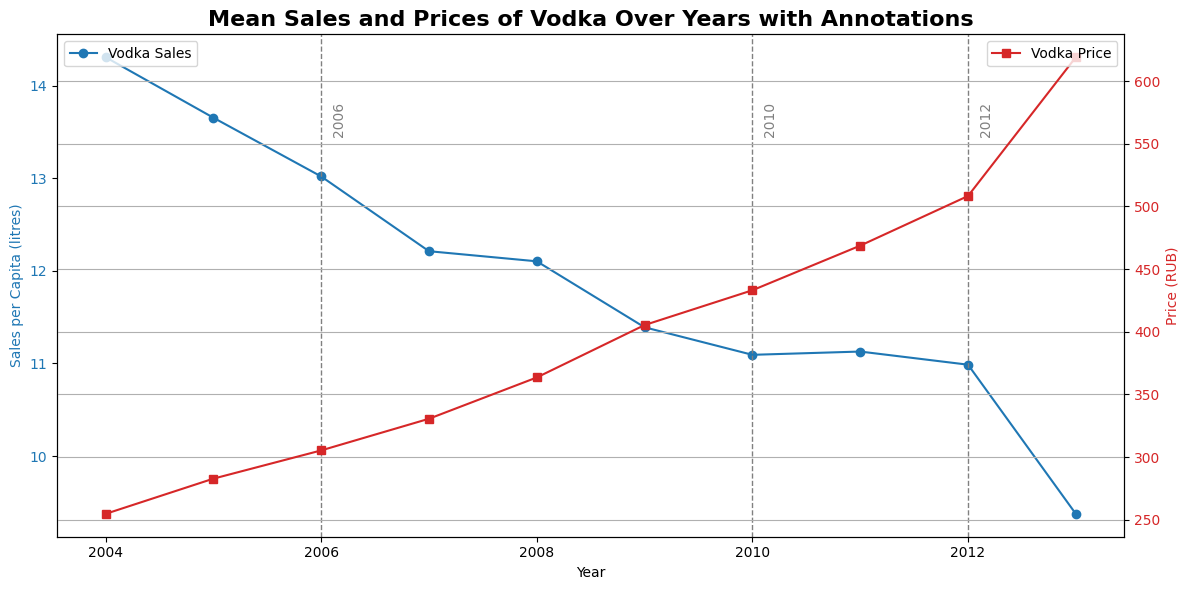

In [64]:
df_clean = df_price[['year', 'sellVodka', 'priceVodka']].dropna()
df_yearly_mean = df_clean.groupby('year', as_index=False).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Sales
ax1.set_xlabel('Year')
ax1.set_ylabel('Sales per Capita (litres)', color='tab:blue')
ax1.plot(df_yearly_mean['year'], df_yearly_mean['sellVodka'], color='tab:blue', marker='o', label='Vodka Sales')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')

# Plot Prices
ax2 = ax1.twinx()
ax2.set_ylabel('Price (RUB)', color='tab:red')
ax2.plot(df_yearly_mean['year'], df_yearly_mean['priceVodka'], color='tab:red', marker='s', label='Vodka Price')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

for year in [2006, 2010, 2012]:
    ax1.axvline(x=year, color='gray', linestyle='--', linewidth=1)
    ax1.text(year + 0.1, ax1.get_ylim()[1]*0.95, f'{year}', rotation=90, verticalalignment='top', color='gray')

plt.title('Mean Sales and Prices of Vodka Over Years with Annotations', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.grid(True)
plt.show()

## 3. Data Analysis
Describe your data analysis and explain what you've learned about the dataset.
If relevant, talk about your machine-learning.

Since our story centers around how alcohol control policies impacted health outcomes, we explored whether **higher overall alcohol sales per capita** were associated with **increased mortality**.

To normalize regional differences in population and reporting, we used the **log of total mortality rates**, then plotted this against alcohol sales across all regions and years:


The relationship appears **slightly positive**, but still relatively weak. This suggests that while alcohol consumption may contribute to higher mortality, the relationship is not strongly linear—likely due to the influence of **unrecorded alcohol**, **poisoning deaths**, and **lagged health effects**. These findings encouraged us to shift focus toward **policy reforms**, **price changes**, and **regional enforcement**, rather than attempting to model mortality directly from sales data alone.

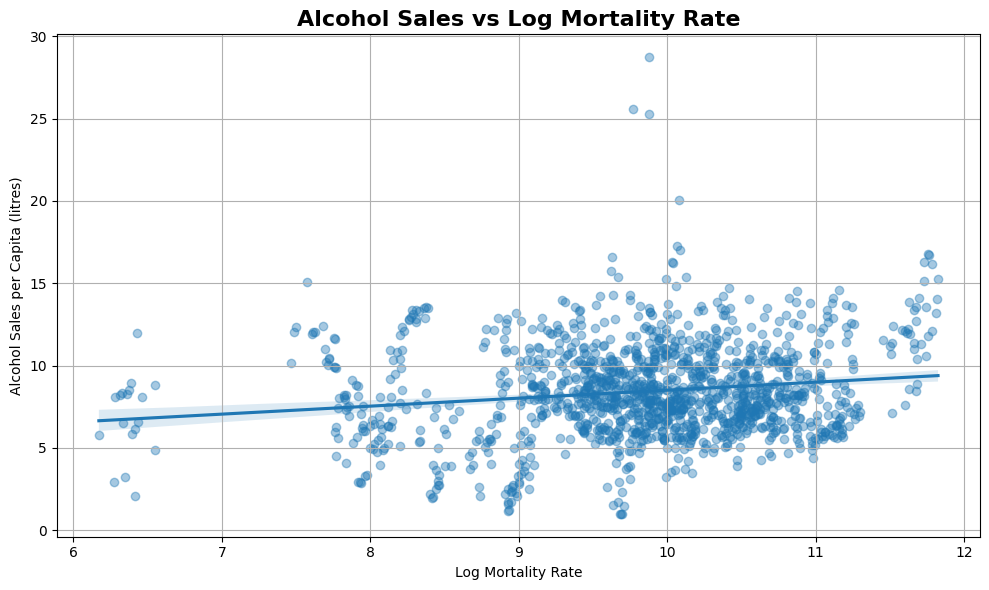

In [61]:
df_clean = df_sales[['log_mortality_all', 'alcohol_sales', 'year']].dropna()

# Scatterplot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='log_mortality_all', y='alcohol_sales', scatter_kws={'alpha': 0.4})
plt.title('Alcohol Sales vs Log Mortality Rate', fontsize=16, fontweight='bold')
plt.xlabel('Log Mortality Rate')
plt.ylabel('Alcohol Sales per Capita (litres)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Regional Trends in Vodka Consumption

To explore how different parts of Russia responded to national alcohol policies, we compared the top 5 regions with the largest increase in vodka sales to the bottom 5 with the steepest decline.

The line plot below shows vodka sales per capita over time for each of these ten regions, with dashed lines indicating decreasing regions and solid lines indicating increasing ones.

This comparison reveals key regional differences:
- Some regions, such as Primorsky Krai and Chukotka Autonomous Okrug, saw substantial declines in vodka consumption, aligning with the national reform timeline.
- Others, like Arkhangelsk Oblast and Republic of Adygea, showed surprising increases despite the policy efforts.

These variations highlight that national policy effectiveness was uneven, potentially due to differences in enforcement, illicit markets, or local culture. This also emphasizes why regional data is crucial for understanding the real-world impact of federal reforms.

We also included each region's federal district to emphasize how broader administrative areas may influence local trends.

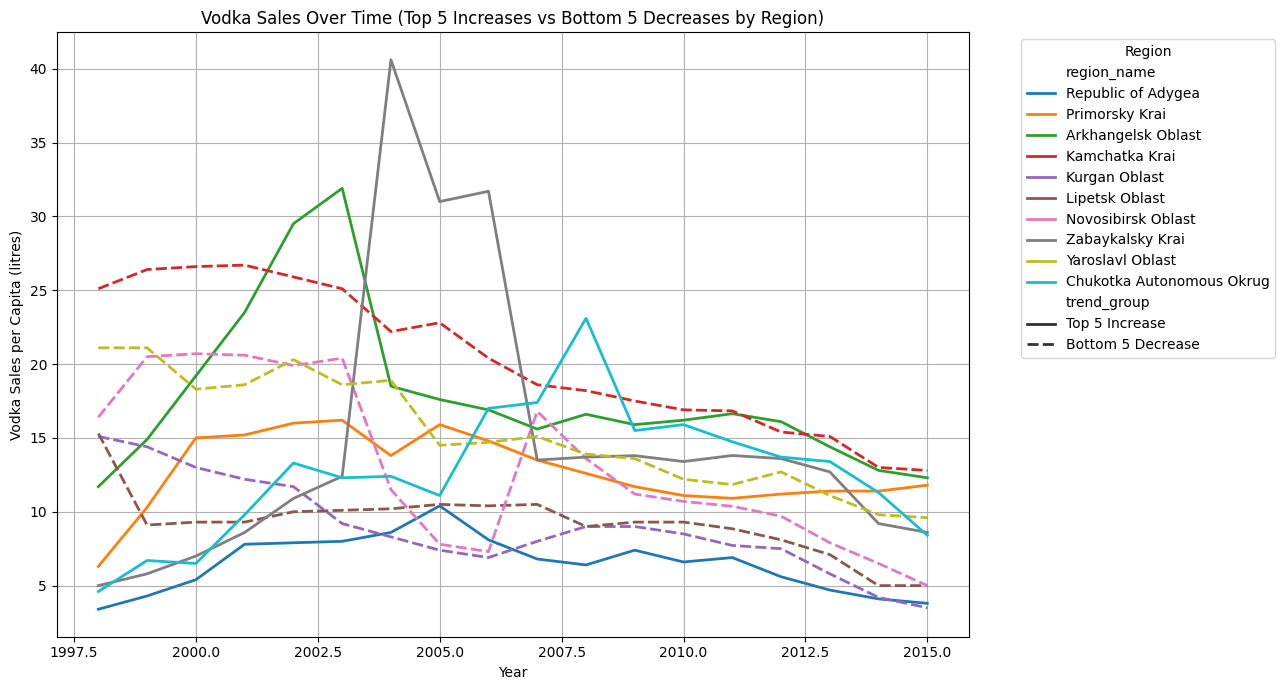

In [72]:
df_change = df_sales[df_sales["year"].isin([1998, 2015])][["region_name", "year", "sellVodka"]]

# Pivot to wide format to calculate change
df_pivot = df_change.pivot(index="region_name", columns="year", values="sellVodka").dropna()
df_pivot["change"] = df_pivot[2015] - df_pivot[1998]

# Identify top 5 and bottom 5 regions
top_5 = df_pivot.sort_values("change", ascending=False).head(5).index
bottom_5 = df_pivot.sort_values("change", ascending=True).head(5).index
selected_regions = top_5.union(bottom_5)

# Filter full dataset for selected regions
df_selected = df_sales[df_sales["region_name"].isin(selected_regions)].copy()

# Label each region as top or bottom
df_selected["trend_group"] = df_selected["region_name"].apply(
    lambda x: "Top 5 Increase" if x in top_5 else "Bottom 5 Decrease"
)

# Merge federal district info
region_fed_map = df_sales[["region_name", "fedokrug_name"]].drop_duplicates()
df_selected = df_selected.merge(region_fed_map, on="region_name", how="left")

# Plot the trends
plt.figure(figsize=(13, 7))
sns.lineplot(data=df_selected, x="year", y="sellVodka", hue="region_name", style="trend_group", linewidth=2)
plt.title("Vodka Sales Over Time (Top 5 Increases vs Bottom 5 Decreases by Region)")
plt.xlabel("Year")
plt.ylabel("Vodka Sales per Capita (litres)")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Region")
plt.tight_layout()
plt.show()


4. Genre. Which genre of data story did you use?
Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?
Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why?


### Alcohol Consumption
- What genre of data story?\
*Explanatory*. It guides the user through a structured narrative about policy, sales trends, and regional outcomes

Segal & Heer Visual Narrative Tools:

- Annotations: Used in Figures 3-5 to mark policies (e.g., 2006, 2010, 2012)
- Reference Lines & Areas: Dashed lines and shaded boxes to show policy periods
- Temporal  Ordering: The stacked area chart, price line chart, and share trends all show chronological changes, guiding the viewer through time.

Narrative Structure Tools:

- Martini Glass: Users are guided through the policy effects first, then allowed to explore regional differences with the map (interactive discovery at the end)
- Drill-down: The choropleth map allows deeper exporeation by year and region
- Interactive Widgets: Year slider and play button help users explore data transitions over time.

5. Visualizations.
Explain the visualizations you've chosen.
Why are they right for the story you want to tell?

- Stacked Area Chart: Shows overall alcohol sales and highlights the relative scale and shift of beverage types over time.
- Line Chart for Prices: Highlights how vodka became more expensive post-2010, showing price-policy link.
- Line Chart for Beverage Share: Shows how vodka lost dominance to beer—perfect for reflecting changing preferences.
- Choropleth Map: Adds spatial depth, users see how different federal districts (regions) reacted over time.

They reflect temporal and regional changes in a simple, accessible way. They also support the narrative flow from national policy to individual regions.

6. Discussion. Think critically about your creation
What went well?,
What is still missing? What could be improved?, Why?

What went well?
- Clear patterns emerged showing how policy timing aligned with behavioral change
- Visualization choices made temporal and geographic patterns easy to grasp
- The intergration of slider and animated map enhanced interactivity

What could be improved?
- Hard to find academic refrences supporting specific causal claims.
- More economic context (e.g., income or unemployment) could strengthen the analysis.

Unexpected insights?
- It was surprising how long it took for beer to overtake vodka in share (~2015).
- Federal district differences were more extreme than anticipated, some regions hardly changed while others shifted quickly.

7. Contributions. Who did what?
You should write (just briefly) which group member was the main responsible for which elements of the assignment. (I want you guys to understand every part of the assignment, but usually there is someone who took lead role on certain portions of the work. That's what you should explain).